# CNS — communication, navigation, surveillance

The three CNS ingredients of a BlueSkyCDaRR run, demonstrated **empirically on a
live BlueSky sim**: the engine (the CDaRR fork) is initialised, aircraft are
created and integrated by BlueSky, and every truth sample below is read out of
`bs.traf` — the same boundary `run_episode` reads through (`blueskycdarr/engine.py`).
The CNS layers then measure that engine truth with the package's own components:

1. **Navigation uncertainty** — a hovering M600 logs its own GNSS fix at the CDR
   cadence; three position-error distributions, all delivering the same 95%
   radial containment (`blueskycdarr.noise`, ADR 0007).
2. **Broadcast jitter and reception probability** — the hovering ownship logs the
   *contact* it holds of a BlueSky-flown intruder, fed by the event-based
   broadcast channel (`blueskycdarr.adsl.BroadcastChannel`, ADR 0002); two reception
   probabilities.
3. **Surveillance range** — the hard range gate: a broadcast from farther than
   `max_range_m` at transmit time is never received.
4. **All three combined** — the study-baseline uncertainty and channel over the
   same pass: what the ownship's picture of the intruder actually looks like.

Run top to bottom with the project venv. BlueSky is a process-global singleton —
a fresh kernel gives a fresh sim, and every section resets the traffic state
before creating its own aircraft.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from blueskycdarr.adsl import BroadcastChannel, ContactTable, noisy_snapshot
from blueskycdarr.config import CommConfig, UncertaintyConfig
from blueskycdarr.engine import ensure_engine
from blueskycdarr.geo import displace, distance_m, enu_offset
from blueskycdarr.noise import AnisotropicGaussian, Gaussian, MixtureGaussian
from blueskycdarr.state import StateArrays

ensure_engine()  # bs.init(detached) once per process + verifies the CDaRR fork
import bluesky as bs
from bluesky.tools.aero import vtas2cas

ALT_M = 100.0
HOME_LAT, HOME_LON = 52.3, 4.7  # engine.py's spawn neighbourhood


def to_cas(gs_ms):
    """Ground speed -> the CAS BlueSky's cre/SPD expect (engine.py's boundary rule)."""
    return float(vtas2cas(gs_ms, ALT_M))


def truth_from_engine():
    """The ground-truth state table, copied out of the engine (PairwiseWorld.truth)."""
    traf = bs.traf
    return StateArrays(
        lat=np.array(traf.lat, dtype=float), lon=np.array(traf.lon, dtype=float),
        trk=np.array(traf.trk, dtype=float), gs=np.array(traf.gs, dtype=float),
        gs_east=np.array(traf.gseast, dtype=float),
        gs_north=np.array(traf.gsnorth, dtype=float),
    )


BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"  # categorical slots, fixed order
INK, MUTED = "#0b0b0b", "#52514e"

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True, "grid.color": "#e5e4e0", "grid.linewidth": 0.6,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK,
    "axes.titlesize": 10.5, "axes.titleweight": "bold",
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False,
})


## 1. Navigation uncertainty — a hovering drone's GNSS log

An M600 is created in BlueSky with commanded speed 0 (a multirotor may stop —
`MULTIROTOR.v_min = 0`) and heading held at 45°, and the sim is stepped at the
package's integration step (`dt = 0.2 s`) for 20 minutes. Once per second — the
CDR cadence, exactly when `run_episode` samples its own-navigation view — the
engine truth is read out and measured with `noisy_snapshot`: truth plus fresh
noise from a pluggable position-error **shape** (ADR 0007). Every shape delivers
the same containment guarantee — the 95th percentile of the 2D radial error
equals the configured `pos_ci95` exactly (solved by bisection in
`blueskycdarr/noise.py`) — so the three logs differ only in *shape*:

- **Gaussian** — the isotropic default;
- **MixtureGaussian** — 10% of fixes come from a 3× wider tail (heavy tail);
- **AnisotropicGaussian** — along-track variance 3× cross-track, oriented by the
  track the shape is handed. A hovering drone has no track from motion; the
  engine reports `trk = hdg` at zero ground speed, so the ellipse aligns to the
  held 45° heading.

`pos_ci95 = 30 m`, one of the study's ADS-L accuracy classes. The printout
verifies the sim actually hovered (engine truth: zero drift, zero ground speed)
— every scatter below is measurement error, not motion.


In [2]:
CI95 = 30.0     # configured 95% radial containment [m]
HEADING = 45.0  # held heading while hovering [deg]
N_FIX = 1200    # one fix per second, 20 min of sim time
DT_HOVER, STEPS_PER_FIX = 0.2, 5

SHAPES = [
    ("Gaussian", Gaussian(), BLUE),
    ("MixtureGaussian", MixtureGaussian(), ORANGE),
    ("AnisotropicGaussian", AnisotropicGaussian(), AQUA),
]

bs.traf.reset()
bs.stack.stack(f"DT {DT_HOVER}")
bs.traf.cre(acid="HOV", actype="M600", aclat=HOME_LAT, aclon=HOME_LON,
            achdg=HEADING, acalt=ALT_M, acspd=to_cas(0.0))

unc_nav = UncertaintyConfig(pos_ci95=CI95)
rngs = {name: np.random.default_rng(7) for name, _, _ in SHAPES}
err = {name: np.empty((N_FIX, 2)) for name, _, _ in SHAPES}
truth_log = np.empty((N_FIX, 4))  # lat, lon, gs, trk per fix

for k in range(N_FIX):
    truth = truth_from_engine()
    truth_log[k] = truth.lat[0], truth.lon[0], truth.gs[0], truth.trk[0]
    for name, shape, _ in SHAPES:
        fix = noisy_snapshot(truth, np.array([0]), unc_nav, rngs[name], shape)
        e, n = enu_offset(truth.lat, truth.lon, fix.lat, fix.lon)
        err[name][k] = e[0], n[0]
    for _ in range(STEPS_PER_FIX):
        bs.sim.step()

drift = distance_m(truth_log[0, 0], truth_log[0, 1], truth_log[:, 0], truth_log[:, 1])
print(f"engine truth over {N_FIX} fixes: max drift from spawn {drift.max():.3f} m, "
      f"max ground speed {truth_log[:, 2].max():.3f} m/s, "
      f"reported trk {truth_log[:, 3].min():.0f}\u2013{truth_log[:, 3].max():.0f} deg")
logs = {name: (err[name][:, 0], err[name][:, 1]) for name, _, _ in SHAPES}
for name, _, _ in SHAPES:
    east, north = logs[name]
    r95 = np.percentile(np.hypot(east, north), 95)
    print(f"{name:22s} radial 95th percentile {r95:5.1f} m   (configured {CI95:.0f} m)")


engine truth over 1200 fixes: max drift from spawn 0.000 m, max ground speed 0.000 m/s, reported trk 45–45 deg
Gaussian               radial 95th percentile  29.6 m   (configured 30 m)
MixtureGaussian        radial 95th percentile  31.4 m   (configured 30 m)
AnisotropicGaussian    radial 95th percentile  29.3 m   (configured 30 m)


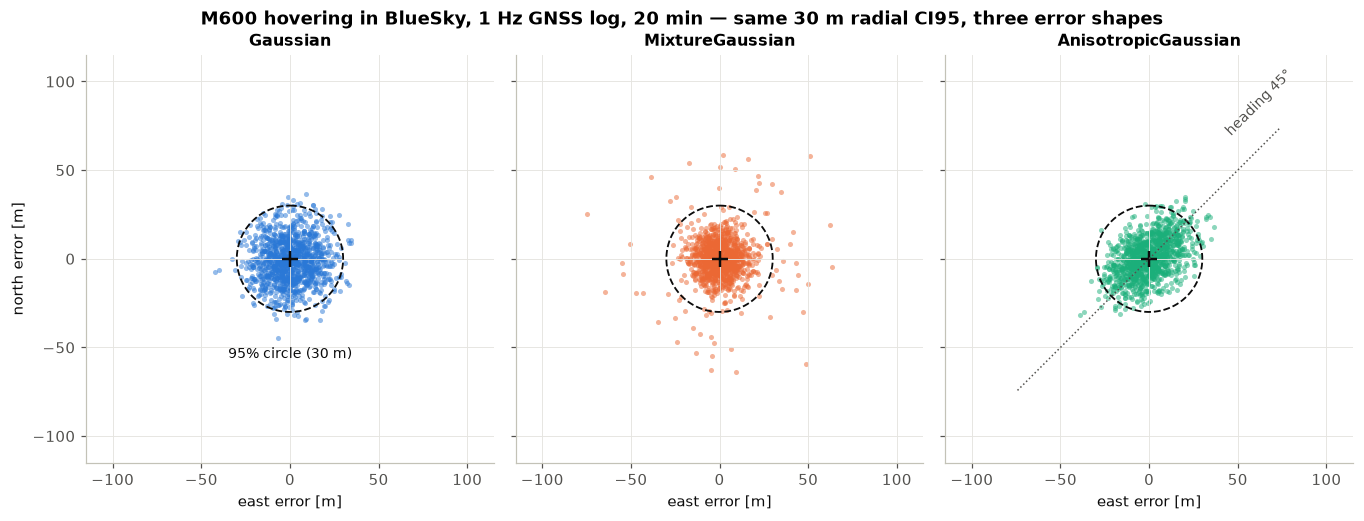

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.5), sharex=True, sharey=True)
theta = np.linspace(0.0, 2.0 * np.pi, 200)
for ax, (name, _, color) in zip(axes, SHAPES):
    east, north = logs[name]
    ax.scatter(east, north, s=11, color=color, alpha=0.5, linewidths=0)
    ax.plot(CI95 * np.sin(theta), CI95 * np.cos(theta), color=INK, lw=1.2, ls="--")
    ax.plot(0.0, 0.0, marker="+", color=INK, ms=10, mew=1.6)
    ax.set_title(name)
    ax.set_xlabel("east error [m]")
    ax.set_aspect("equal")
axes[0].set_ylabel("north error [m]")
axes[0].set_xlim(-115, 115)
axes[0].set_ylim(-115, 115)
axes[0].annotate("95% circle (30 m)", xy=(0, -CI95), xytext=(0, -56),
                 ha="center", color=INK, fontsize=9)
h = np.radians(HEADING)
axes[2].plot([-105 * np.sin(h), 105 * np.sin(h)], [-105 * np.cos(h), 105 * np.cos(h)],
             color=MUTED, lw=1.0, ls=":")
axes[2].annotate("heading 45°", xy=(62, 88), color=MUTED, fontsize=9,
                 rotation=45, ha="center", va="center")
fig.suptitle("M600 hovering in BlueSky, 1 Hz GNSS log, 20 min — same 30 m radial CI95, "
             "three error shapes", fontweight="bold")
fig.tight_layout()
plt.show()


The containment guarantee, seen from the log: the three empirical CDFs of radial
error cross **P = 0.95 at the same 30 m**. The bodies differ — the mixture's tight
core rises fastest but pays for it with a long tail; the anisotropic shape spreads
its error along one axis.


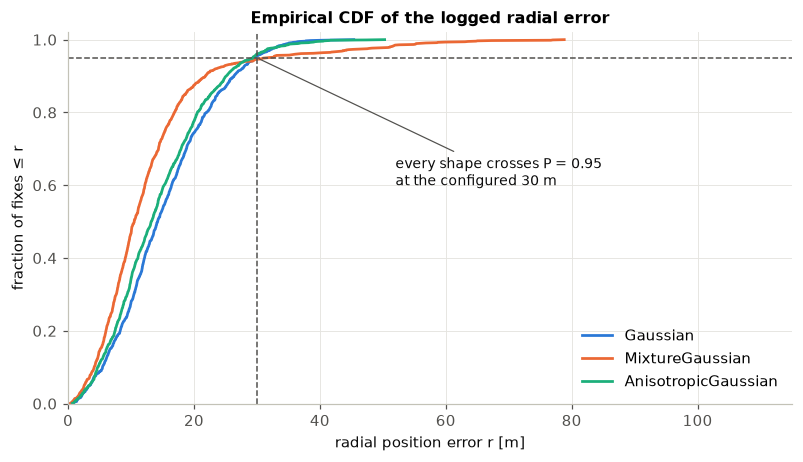

In [4]:
fig, ax = plt.subplots(figsize=(7.4, 4.3))
for name, _, color in SHAPES:
    east, north = logs[name]
    r = np.sort(np.hypot(east, north))
    ax.plot(r, np.arange(1, r.size + 1) / r.size, color=color, lw=1.8, label=name)
ax.axvline(CI95, color=MUTED, lw=1.0, ls="--")
ax.axhline(0.95, color=MUTED, lw=1.0, ls="--")
ax.annotate("every shape crosses P = 0.95\nat the configured 30 m", xy=(CI95, 0.95),
            xytext=(52, 0.60), fontsize=9, color=INK,
            arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))
ax.set_xlim(0, 115)
ax.set_ylim(0, 1.02)
ax.set_xlabel("radial position error r [m]")
ax.set_ylabel("fraction of fixes ≤ r")
ax.set_title("Empirical CDF of the logged radial error")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()


## 2. Broadcast jitter and reception probability — logging a contact

Communication is event-based (`BroadcastChannel`, ADR 0002): each aircraft
transmits on its own schedule, `interval + U(−jitter, +jitter)` apart; each
transmission is a snapshot of the transmit-time state; it is received iff a
Bernoulli(`reception_prob`) succeeds; the receiver **holds the last delivered
message** — a stale contact, never extrapolated (CDaRR's holdover).

Here BlueSky flies the pair: the ownship hovers while an intruder M600 crosses
eastbound at a commanded 15 m/s ground speed (converted to CAS at the boundary,
as `engine.py` does — the printout confirms the engine flew exactly 15). The
loop drives the channel exactly as `run_episode` does — `transmit_due(t)`, then
`deliver_due(t)`, every engine step — and logs the contact the ownship holds.
Interval 1 s, jitter ±0.3 s, and **measurement noise off** (`pos_ci95 = 0`) so
the held position is exactly the transmit-time engine truth: every feature of
the staircase is the channel's doing, not the sensor's.

Two reception probabilities, 0.9 and 0.5, with **the same seed**: BlueSky's
truth is deterministic and the broadcast schedule and per-transmission reception
uniforms replay identically (common random numbers, ADR 0004), so the p = 0.5
row loses a superset of the p = 0.9 row's broadcasts — differences between the
rows are the threshold, not luck. What to look for:

- the tread *starts* dither by the jitter (delivered dots are not 1 s apart);
- a lost broadcast (×) stretches a tread to roughly an integer multiple of the
  interval — the receiver flies on stale data for that long;
- the update-gap histogram: jitter smears the mass around 1 s, losses put mass
  near 2 s, 3 s, … with mean gap ≈ interval / p.


In [5]:
def run_channel_sim(comm, *, T, dt=0.05, intr_start_east=-225.0, intr_north=0.0,
                    intr_hdg=90.0, intr_gs=15.0, intr_actype="M600",
                    unc=UncertaintyConfig(), shape=Gaussian(), seed=7):
    """BlueSky flies a hovering ownship and a straight-line intruder; the package's
    BroadcastChannel is driven exactly as run_episode drives it — transmit_due(t),
    then deliver_due(t), every engine step — and the ownship's held contact logged.

    Measurement noise is off by default (unc=UncertaintyConfig() -> perfect
    snapshots), so the held contact is exactly the transmit-time engine truth and
    whatever structure the log shows is the channel's — jitter, losses, range gate.
    Pass unc (and a noise shape) to switch the sensor on, as section 4 does.
    """
    bs.traf.reset()
    bs.stack.stack(f"DT {dt}")
    lat1, lon1 = displace(HOME_LAT, HOME_LON, intr_start_east, intr_north)
    bs.traf.cre(acid="OWN", actype="M600", aclat=HOME_LAT, aclon=HOME_LON,
                achdg=45.0, acalt=ALT_M, acspd=to_cas(0.0))
    bs.traf.cre(acid="INT", actype=intr_actype, aclat=float(lat1), aclon=float(lon1),
                achdg=intr_hdg, acalt=ALT_M, acspd=to_cas(intr_gs))

    meas, rx, sched = np.random.SeedSequence(seed).spawn(3)
    channel = BroadcastChannel(
        comm=comm, uncertainty=unc,
        rng_measurement=np.random.default_rng(meas),
        rng_reception=np.random.default_rng(rx),
        rng_schedule=np.random.default_rng(sched),
        shape=shape,
    )
    channel.initialise(2)
    contacts = ContactTable.empty(truth_from_engine())

    n_steps = int(round(T / dt)) + 1
    log = {k: np.full(n_steps, np.nan)
           for k in ("t", "true_east", "true_north", "held_east", "held_north",
                     "t_tx", "dist", "gs_intr")}
    log["valid"] = np.zeros(n_steps, dtype=bool)
    for step in range(n_steps):
        t = step * dt
        truth = truth_from_engine()
        channel.transmit_due(t, truth)
        channel.deliver_due(t, contacts)
        log["t"][step] = t
        e, n = enu_offset(truth.lat[0:1], truth.lon[0:1], truth.lat[1:2], truth.lon[1:2])
        log["true_east"][step], log["true_north"][step] = e[0], n[0]
        log["dist"][step] = float(distance_m(truth.lat[0], truth.lon[0],
                                             truth.lat[1], truth.lon[1]))
        log["gs_intr"][step] = truth.gs[1]
        if contacts.valid[1]:  # row 1 = the last delivered broadcast FROM the intruder
            he, hn = enu_offset(truth.lat[0:1], truth.lon[0:1],
                                contacts.states.lat[1:2], contacts.states.lon[1:2])
            log["held_east"][step], log["held_north"][step] = he[0], hn[0]
            log["t_tx"][step] = contacts.t_tx[1]
            log["valid"][step] = True
        bs.sim.step()
    return log


def delivery_steps(log):
    """Log indices at which a fresh broadcast landed (the held t_tx moves)."""
    tx = np.where(log["valid"], log["t_tx"], -1.0)
    return np.flatnonzero(np.diff(tx, prepend=-1.0) > 0)


T_RUN, ZOOM_S = 300.0, 30.0
CHANNEL = dict(broadcast_interval_s=1.0, broadcast_jitter_s=0.3)

runs = {p: run_channel_sim(CommConfig(reception_prob=p, **CHANNEL), T=T_RUN)
        for p in (0.9, 0.5)}
ref = run_channel_sim(CommConfig(reception_prob=1.0, **CHANNEL), T=T_RUN)
tx_times = ref["t"][delivery_steps(ref)]  # p = 1: every transmission is delivered

print(f"engine flew the intruder at {ref['gs_intr'].mean():.4f} m/s ground "
      f"(commanded 15, CAS-converted at the boundary)")
for p, log in runs.items():
    d = delivery_steps(log)
    gaps = np.diff(log["t"][d])
    print(f"p = {p}: {d.size}/{tx_times.size} broadcasts delivered "
          f"(empirical rate {d.size / tx_times.size:.2f}), "
          f"mean update gap {gaps.mean():.2f} s (interval / p = {1.0 / p:.2f} s)")


engine flew the intruder at 15.0000 m/s ground (commanded 15, CAS-converted at the boundary)
p = 0.9: 267/298 broadcasts delivered (empirical rate 0.90), mean update gap 1.13 s (interval / p = 1.11 s)
p = 0.5: 153/298 broadcasts delivered (empirical rate 0.51), mean update gap 1.97 s (interval / p = 2.00 s)


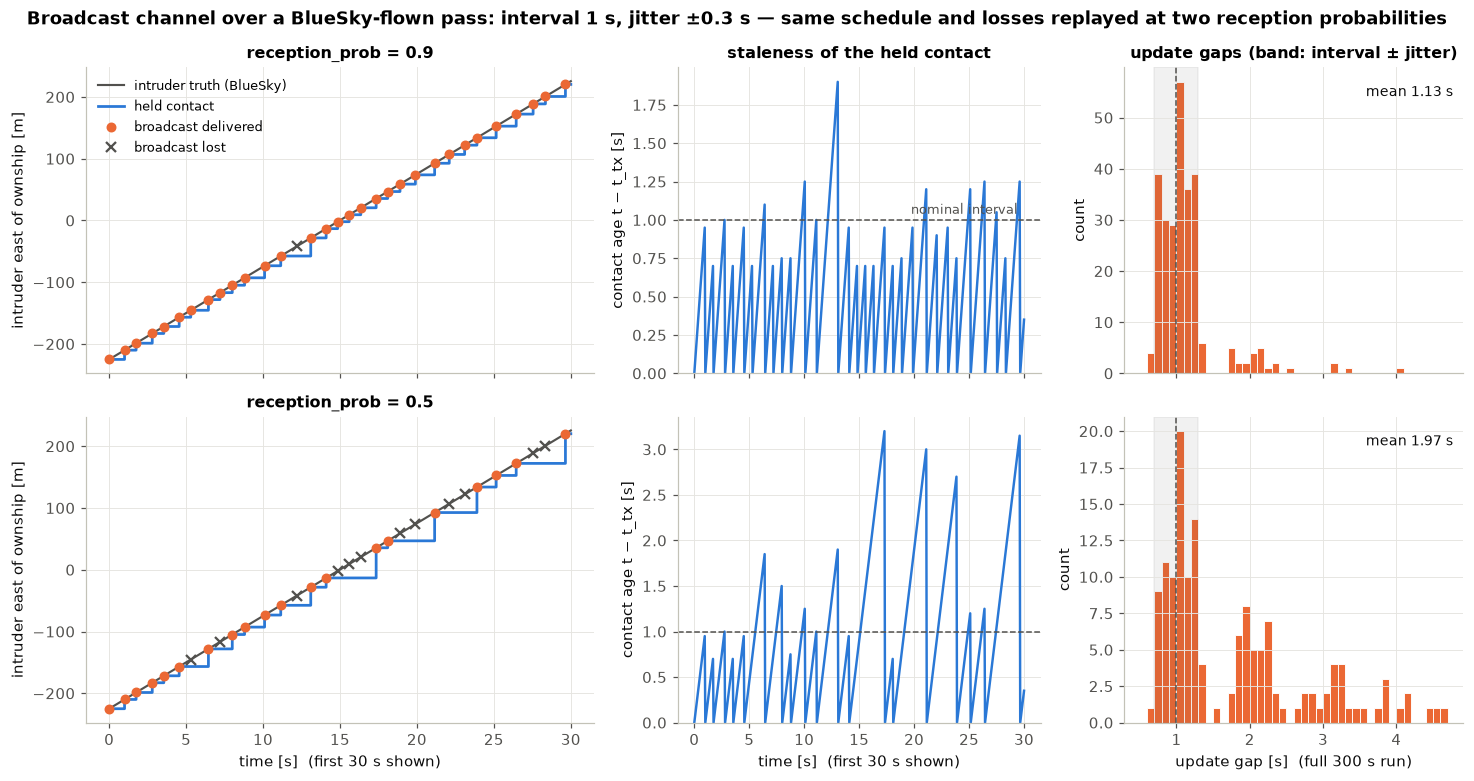

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(13.5, 7.2), sharex="col",
                         gridspec_kw={"width_ratios": [2.1, 1.5, 1.4]})
for row, (p, log) in enumerate(runs.items()):
    d = delivery_steps(log)
    t_d = log["t"][d]
    zoom = log["t"] <= ZOOM_S

    ax = axes[row, 0]
    ax.plot(log["t"][zoom], log["true_east"][zoom], color=MUTED, lw=1.4,
            label="intruder truth (BlueSky)")
    ax.step(log["t"][zoom], log["held_east"][zoom], where="post", color=BLUE, lw=1.8,
            label="held contact")
    in_zoom = t_d <= ZOOM_S
    ax.plot(t_d[in_zoom], log["held_east"][d][in_zoom], "o", color=ORANGE, ms=5.5,
            label="broadcast delivered")
    lost = tx_times[(tx_times <= ZOOM_S) & ~np.isin(np.round(tx_times, 6), np.round(t_d, 6))]
    ax.plot(lost, np.interp(lost, log["t"], log["true_east"]), "x", color=MUTED, ms=7,
            mew=1.5, label="broadcast lost")
    ax.set_title(f"reception_prob = {p}")
    ax.set_ylabel("intruder east of ownship [m]")

    ax = axes[row, 1]
    age = log["t"] - log["t_tx"]  # NaN before the first delivery
    ax.plot(log["t"][zoom], age[zoom], color=BLUE, lw=1.6)
    ax.axhline(CHANNEL["broadcast_interval_s"], color=MUTED, lw=1.0, ls="--")
    ax.set_ylabel("contact age t − t_tx [s]")
    ax.set_ylim(0, None)

    ax = axes[row, 2]
    gaps = np.diff(t_d)
    ax.hist(gaps, bins=np.arange(0.5, 4.75, 0.1), color=ORANGE,
            edgecolor="white", linewidth=0.6)
    ax.axvline(1.0, color=MUTED, lw=1.0, ls="--")
    ax.axvspan(0.7, 1.3, color=MUTED, alpha=0.08)
    ax.set_ylabel("count")
    ax.annotate(f"mean {gaps.mean():.2f} s", xy=(0.97, 0.94), xycoords="axes fraction",
                ha="right", va="top", fontsize=9, color=INK)

axes[0, 0].legend(loc="upper left", fontsize=8.5)
axes[0, 1].set_title("staleness of the held contact")
axes[0, 1].annotate("nominal interval", xy=(ZOOM_S, CHANNEL["broadcast_interval_s"]),
                    xytext=(-4, 4), textcoords="offset points", ha="right",
                    fontsize=8.5, color=MUTED)
axes[0, 2].set_title("update gaps (band: interval ± jitter)")
axes[1, 0].set_xlabel(f"time [s]  (first {ZOOM_S:.0f} s shown)")
axes[1, 1].set_xlabel(f"time [s]  (first {ZOOM_S:.0f} s shown)")
axes[1, 2].set_xlabel(f"update gap [s]  (full {T_RUN:.0f} s run)")
fig.suptitle("Broadcast channel over a BlueSky-flown pass: interval 1 s, jitter ±0.3 s — "
             "same schedule and losses replayed at two reception probabilities",
             fontweight="bold")
fig.tight_layout()
plt.show()


## 3. Surveillance range — the hard gate

`CommConfig.max_range_m` is transmit-path physics: a broadcast is received iff the
Bernoulli succeeds **and** the true distance at transmit time is within the gate.
And a contact starts *invalid* — an aircraft that has never been heard does not
exist to its counterpart (deviation D2 from CDaRR's guaranteed first copy), which
is exactly what a range gate must be able to express.

BlueSky flies the catalog's fixed-wing this time (it flies under the `Amzn`
carrier id, ADR 0005) at its envelope top of 25 m/s, from 4 km west to 4.25 km
east of the hovering ownship, offset 600 m north; the gate is 3000 m, reception
probability 1 and jitter 0, so the gate is the only physics left. The ownship
hears nothing until the intruder crosses into range, tracks it through the pass,
and after it exits the contact freezes at the last in-range broadcast while the
truth flies away.


In [7]:
RANGE_M = 3000.0
PASS = dict(T=330.0, intr_start_east=-4000.0, intr_north=600.0,
            intr_gs=25.0, intr_actype="Amzn")

srv = run_channel_sim(CommConfig(reception_prob=1.0, broadcast_interval_s=1.0,
                                 max_range_m=RANGE_M), **PASS)
d_srv = delivery_steps(srv)
t_d = srv["t"][d_srv]
first, last = t_d[0], t_d[-1]
print(f"engine flew the intruder at {srv['gs_intr'].mean():.4f} m/s ground")
print(f"first heard t = {first:6.1f} s, true distance {srv['dist'][d_srv[0]]:6.1f} m")
print(f"last heard  t = {last:6.1f} s, true distance {srv['dist'][d_srv[-1]]:6.1f} m")
print(f"{t_d.size} broadcasts delivered of {int(PASS['T']) + 1} transmitted")

no_gate = run_channel_sim(CommConfig(reception_prob=1.0, broadcast_interval_s=1.0), **PASS)
t0 = no_gate["t"][delivery_steps(no_gate)][0]
print(f"gate off (max_range_m = None): first heard at t = {t0:.1f} s — the very first broadcast")


engine flew the intruder at 25.0000 m/s ground
first heard t =   43.0 s, true distance 2984.4 m
last heard  t =  277.0 s, true distance 2994.2 m
235 broadcasts delivered of 331 transmitted


gate off (max_range_m = None): first heard at t = 0.0 s — the very first broadcast


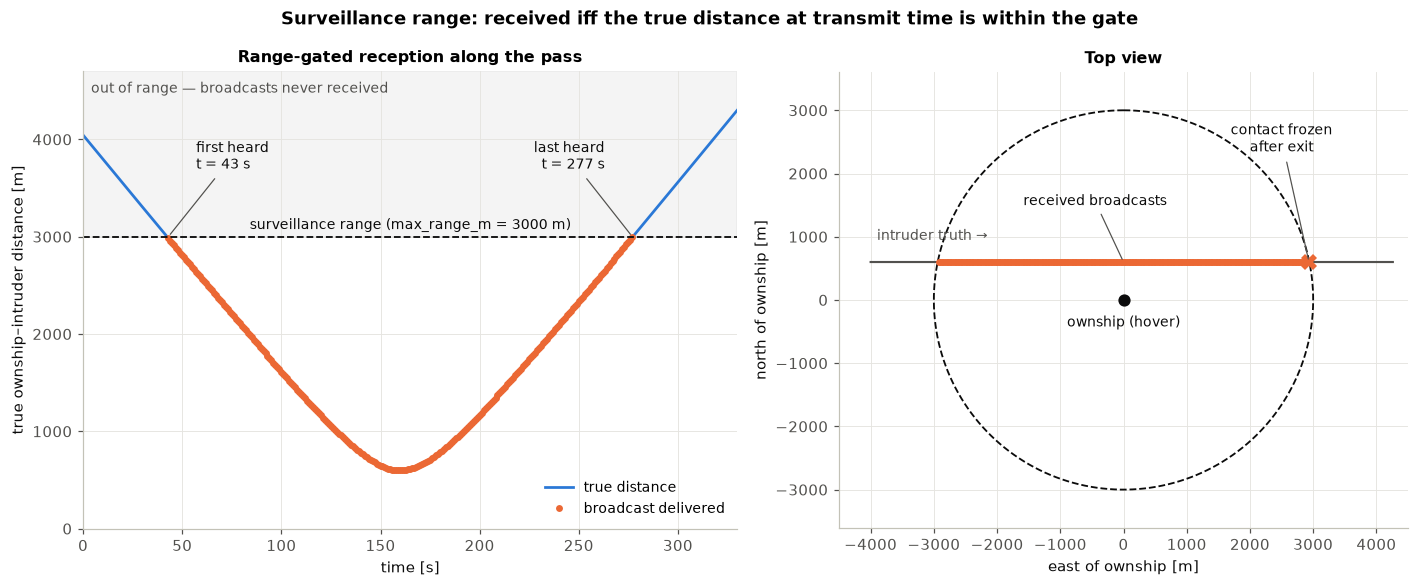

In [8]:
fig, (ax, axm) = plt.subplots(1, 2, figsize=(13.0, 5.4), gridspec_kw={"width_ratios": [1.15, 1]})

ax.plot(srv["t"], srv["dist"], color=BLUE, lw=1.8, label="true distance")
ax.plot(t_d, srv["dist"][d_srv], "o", color=ORANGE, ms=3.5, label="broadcast delivered")
ax.axhline(RANGE_M, color=INK, lw=1.2, ls="--")
ax.axhspan(RANGE_M, 4700, color=MUTED, alpha=0.06)
ax.annotate("surveillance range (max_range_m = 3000 m)", xy=(0.5 * PASS["T"], RANGE_M),
            xytext=(0, 5), textcoords="offset points", ha="center", fontsize=9, color=INK)
ax.annotate("out of range — broadcasts never received", xy=(4, 4480), fontsize=9, color=MUTED)
ax.annotate(f"first heard\nt = {first:.0f} s", xy=(first, RANGE_M), xytext=(first + 14, 3700),
            fontsize=9, color=INK, arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))
ax.annotate(f"last heard\nt = {last:.0f} s", xy=(last, RANGE_M), xytext=(last - 14, 3700),
            ha="right", fontsize=9, color=INK,
            arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))
ax.set_xlim(0, PASS["T"])
ax.set_ylim(0, 4700)
ax.set_xlabel("time [s]")
ax.set_ylabel("true ownship–intruder distance [m]")
ax.set_title("Range-gated reception along the pass")
ax.legend(loc="lower right", fontsize=9)

theta = np.linspace(0.0, 2.0 * np.pi, 200)
axm.plot(RANGE_M * np.sin(theta), RANGE_M * np.cos(theta), color=INK, lw=1.2, ls="--")
axm.plot(srv["true_east"], srv["true_north"], color=MUTED, lw=1.4)
axm.plot(srv["held_east"][d_srv], srv["held_north"][d_srv], "o", color=ORANGE, ms=3.5)
axm.plot(srv["held_east"][-1], srv["held_north"][-1], "X", color=ORANGE, ms=11, mew=0)
axm.plot(0.0, 0.0, "o", color=INK, ms=7)
axm.annotate("ownship (hover)", xy=(0, 0), xytext=(0, -420), ha="center", fontsize=9, color=INK)
axm.annotate("intruder truth →", xy=(-3900, 950), fontsize=9, color=MUTED)
axm.annotate("received broadcasts", xy=(0, 600), xytext=(-450, 1500), ha="center",
             fontsize=9, color=INK, arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))
axm.annotate("contact frozen\nafter exit", xy=(srv["held_east"][-1], srv["held_north"][-1]),
             xytext=(2500, 2350), ha="center", fontsize=9, color=INK,
             arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))
axm.set_aspect("equal")
axm.set_xlim(-4500, 4500)
axm.set_ylim(-3600, 3600)
axm.set_xlabel("east of ownship [m]")
axm.set_ylabel("north of ownship [m]")
axm.set_title("Top view")
fig.suptitle("Surveillance range: received iff the true distance at transmit time is within the gate",
             fontweight="bold")
fig.tight_layout()
plt.show()


## 4. All three combined — what the ownship actually knows

The same BlueSky-flown pass as section 3, but nothing is idealised any more: the
condition is the **baseline of `experiment_example.ipynb`** — position CI95 30 m
(Gaussian) and velocity CI95 3 m/s carried by every broadcast, reception
probability 0.8, broadcast jitter ±0.1 s, latency 0.1 s, surveillance range
3000 m. A p = 1 twin with the same seed (same schedule, same measurement draws,
same gate) identifies which in-range broadcasts the Bernoulli dropped.

The observable that combines all three CNS ingredients is the **radial error of
the held contact against where the intruder truly is now**. It has three regimes:

- **never heard** — before the gate is crossed the contact does not exist;
- **tracked** — a sawtooth riding the noise floor: each delivery resets the error
  to roughly the measurement noise (plus the 0.1 s latency, ~2.5 m here), then
  staleness grows it at the intruder's 25 m/s. At a 1 s cadence the staleness
  contribution is the same order as the 30 m sensor class — a missed broadcast
  doubles it;
- **frozen** — after the intruder exits the gate the last contact is held
  forever, and the error grows without bound at 25 m/s.


In [9]:
from dataclasses import replace

UNC_BASE = UncertaintyConfig(pos_ci95=30.0, vel_ci95=3.0)
COMM_BASE = CommConfig(reception_prob=0.8, max_range_m=RANGE_M, latency_s=0.1,
                       broadcast_interval_s=1.0, broadcast_jitter_s=0.1)

cmb = run_channel_sim(COMM_BASE, unc=UNC_BASE, **PASS)
cmb_all = run_channel_sim(replace(COMM_BASE, reception_prob=1.0), unc=UNC_BASE, **PASS)

d_cmb = delivery_steps(cmb)
t_del = cmb["t"][d_cmb]
t_all = cmb_all["t"][delivery_steps(cmb_all)]  # p = 1 twin: every in-range broadcast
lost = t_all[~np.isin(np.round(t_all, 6), np.round(t_del, 6))]
err_r = np.hypot(cmb["held_east"] - cmb["true_east"],
                 cmb["held_north"] - cmb["true_north"])  # NaN while never heard
first_c, last_c = t_del[0], t_del[-1]
tracked = cmb["valid"] & (cmb["t"] <= last_c)

print(f"in-range broadcasts {t_all.size}, delivered {t_del.size} "
      f"(empirical reception rate {t_del.size / t_all.size:.2f}, configured 0.8)")
print(f"first heard t = {first_c:5.1f} s, last heard t = {last_c:5.1f} s")
print(f"radial contact error while tracked: mean {np.nanmean(err_r[tracked]):.1f} m, "
      f"95th pct {np.nanpercentile(err_r[tracked], 95):.1f} m")
print(f"error at t = {cmb['t'][-1]:.0f} s (frozen since exit): {err_r[-1]:.0f} m and growing")


in-range broadcasts 234, delivered 193 (empirical reception rate 0.82, configured 0.8)
first heard t =  43.1 s, last heard t = 276.9 s
radial contact error while tracked: mean 25.7 m, 95th pct 57.0 m
error at t = 330 s (frozen since exit): 1325 m and growing


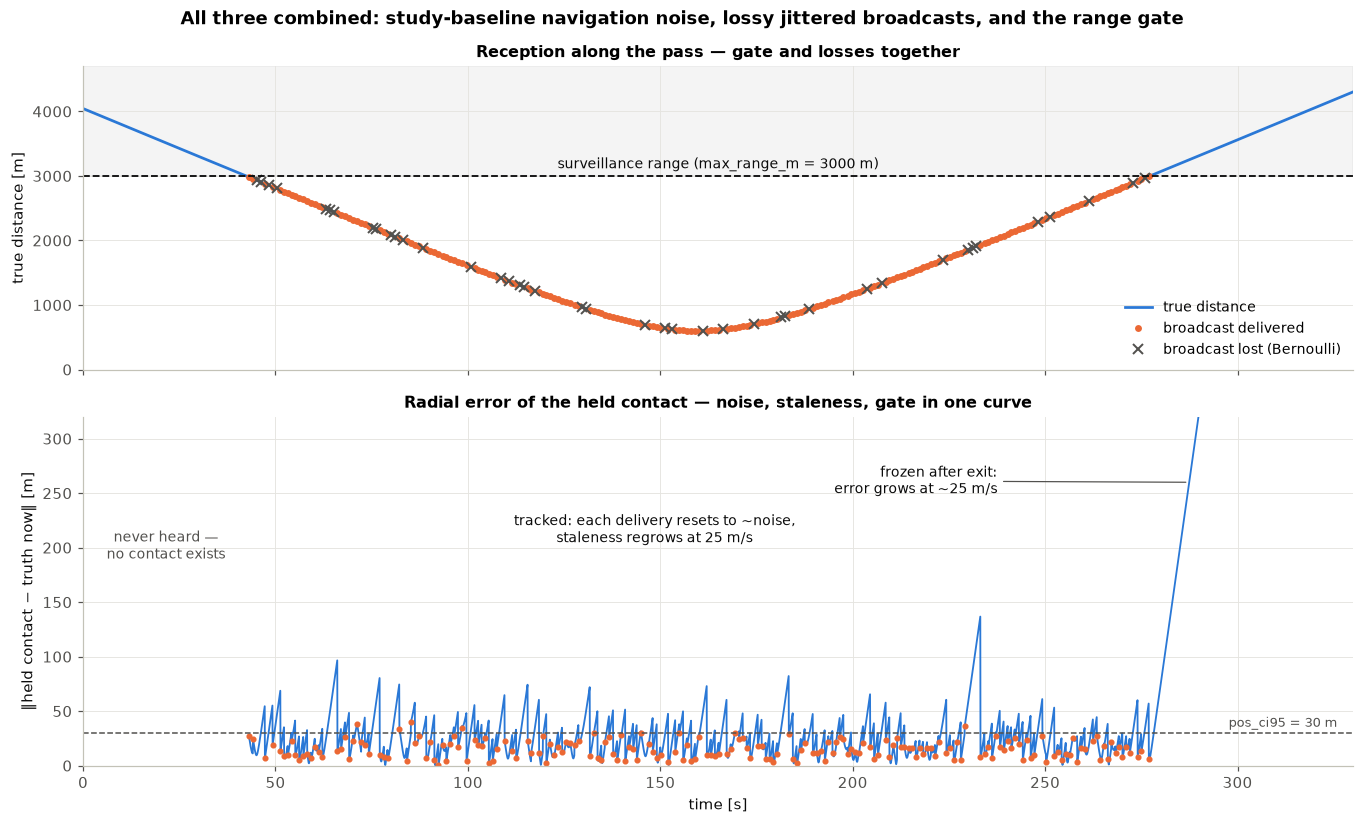

In [10]:
fig, (axd, axe) = plt.subplots(2, 1, figsize=(12.5, 7.6), sharex=True,
                               gridspec_kw={"height_ratios": [1.0, 1.15]})

axd.plot(cmb["t"], cmb["dist"], color=BLUE, lw=1.8, label="true distance")
axd.plot(t_del, np.interp(t_del, cmb["t"], cmb["dist"]), "o", color=ORANGE, ms=3.5,
         label="broadcast delivered")
axd.plot(lost, np.interp(lost, cmb["t"], cmb["dist"]), "x", color=MUTED, ms=6, mew=1.3,
         label="broadcast lost (Bernoulli)")
axd.axhline(RANGE_M, color=INK, lw=1.2, ls="--")
axd.axhspan(RANGE_M, 4700, color=MUTED, alpha=0.06)
axd.annotate("surveillance range (max_range_m = 3000 m)", xy=(0.5 * PASS["T"], RANGE_M),
             xytext=(0, 5), textcoords="offset points", ha="center", fontsize=9, color=INK)
axd.set_ylim(0, 4700)
axd.set_ylabel("true distance [m]")
axd.set_title("Reception along the pass — gate and losses together")
axd.legend(loc="lower right", fontsize=9)

axe.plot(cmb["t"], err_r, color=BLUE, lw=1.2)
axe.plot(t_del, err_r[d_cmb], "o", color=ORANGE, ms=3.0)
axe.axhline(30.0, color=MUTED, lw=1.0, ls="--")
axe.annotate("pos_ci95 = 30 m", xy=(PASS["T"] - 4, 30), xytext=(0, 4),
             textcoords="offset points", ha="right", fontsize=8.5, color=MUTED)
axe.annotate("never heard —\nno contact exists", xy=(first_c / 2, 190),
             ha="center", fontsize=9, color=MUTED)
axe.annotate("tracked: each delivery resets to ~noise,\nstaleness regrows at 25 m/s",
             xy=(0.45 * PASS["T"], 205), ha="center", fontsize=9, color=INK)
axe.annotate("frozen after exit:\nerror grows at ~25 m/s", xy=(last_c + 260 / 25, 260),
             xytext=(0.72 * PASS["T"], 250), ha="right", fontsize=9, color=INK,
             arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))
axe.set_xlim(0, PASS["T"])
axe.set_ylim(0, 320)
axe.set_xlabel("time [s]")
axe.set_ylabel("‖held contact − truth now‖ [m]")
axe.set_title("Radial error of the held contact — noise, staleness, gate in one curve")

fig.suptitle("All three combined: study-baseline navigation noise, lossy jittered broadcasts, "
             "and the range gate", fontweight="bold")
fig.tight_layout()
plt.show()


## Where these knobs live in a real run

Everything above ran on the real engine through the same seams an experiment
uses: `ensure_engine()` initialised BlueSky (and verified the CDaRR fork), truth
was read from `bs.traf` the way `PairwiseWorld.truth()` reads it, speeds crossed
the boundary as CAS the way `engine.py` converts them, and the channel was
driven per step exactly as `run_episode` drives it. In an experiment the same
behaviour is declared, not scripted:

- `Config.uncertainty` — `UncertaintyConfig(pos_ci95=…, vel_ci95=…)`, feeding both
  the ownship's own navigation and the state its broadcasts carry;
- `Config.comm` — `CommConfig(reception_prob=…, broadcast_interval_s=…,
  broadcast_jitter_s=…, max_range_m=…, latency_s=…, broadcast_random_phase=…)`;
- the **noise shape** — `Models(noise=AnisotropicGaussian())` in Python, or
  `noise: {type: anisotropic_gaussian}` in a run file.

Not demoed here: the `LatencyBiased` noise shape (an along-track bias of
`delay_s × gs` — identically zero for a hovering drone); section 4 does carry the
channel's `latency_s = 0.1 s`, but its ~2.5 m contribution at 25 m/s is dwarfed
by staleness. The
reduction to CDaRR's per-tick reception (jitter 0, latency 0, no gate, interval =
CDR cadence) is locked by `tests/test_adsl.py`; what these channel effects do to
P(LoS) is sections 4–5 of `experiment_example.ipynb`.
